# IDS705- Final Project

**Main idea of this file** 
The goal of this analysis is to examine whether diabetes is associated with a higher likelihood of cardiovascular disease (CVD), using a logistic regression model on health survey data.

**Data Plan**
- Source: A cleaned CSV dataset containing individual-level health information(https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators).
- Target Variable: cvd (binary): whether the individual has cardiovascular disease.
- Key Predictor:diabetes (binary): whether the individual has diabetes.
- Preparation Steps: Drop duplicate rows. Reset the index and rename columns for clarity.

**Technical Detail**
- Exploratory Analysis: Compared CVD rates between diabetic and non-diabetic individuals. Used pd.crosstab to examine the relationship.
- Modeling Approach: Logistic Regression via statsmodels.Logit:
- Response: cvd
- Predictor: diabetes (with intercept) Assessed coefficient significance through standard output (z-values, p-values).
- Marginal Effects: Estimated average marginal effects to interpret how diabetes affects CVD probability on the probability scale.



## Data Loading and PreProcessing

In [1]:
# pip install ucimlrepo


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd
# fetch dataset 
cdc_diabetes_health_indicators = fetch_ucirepo(id=891) 
# https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators

X = cdc_diabetes_health_indicators.data.features 
y = cdc_diabetes_health_indicators.data.targets 

In [7]:
# columns
print(X.columns) 
print(y.columns)
# shape
print(X.shape, y.shape) 

Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')
Index(['Diabetes_binary'], dtype='object')
(253680, 21) (253680, 1)


In [2]:
# Age is critical feature related  to our topic- younger CVD
age_map = {
    1: '18-24',
    2: '25-29',
    3: '30-34',
    4: '35-39',
    5: '40-44',
    6: '45-49',
    7: '50-54',
    8: '55-59',
    9: '60-64',
    10: '65-69',
    11: '70-74',
    12: '75-79',
    13: '80+'
}

X['AgeGroup'] = X['Age'].map(age_map)
from pandas.api.types import CategoricalDtype
age_order = list(age_map.values())  
X['AgeGroup'] = X['AgeGroup'].astype(CategoricalDtype(categories=age_order, ordered=True))

df = pd.concat([X, y], axis=1)

/var/folders/nq/n8qjnkmx7wqdsh3y0nxk8tf40000gn/T/ipykernel_36100/1340810243.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['AgeGroup'] = X['Age'].map(age_map)
/var/folders/nq/n8qjnkmx7wqdsh3y0nxk8tf40000gn/T/ipykernel_36100/1340810243.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['AgeGroup'] = X['AgeGroup'].astype(CategoricalDtype(categories=age_order, ordered=True))


**Findings**

- Age is a strong driver of both diabetes and heart disease risk.

- Diabetes significantly increases the risk of heart disease across all ages.

- The relative risk is especially pronounced in younger adults, underlining the need for early cardiovascular screening and intervention in younger diabetic populations.

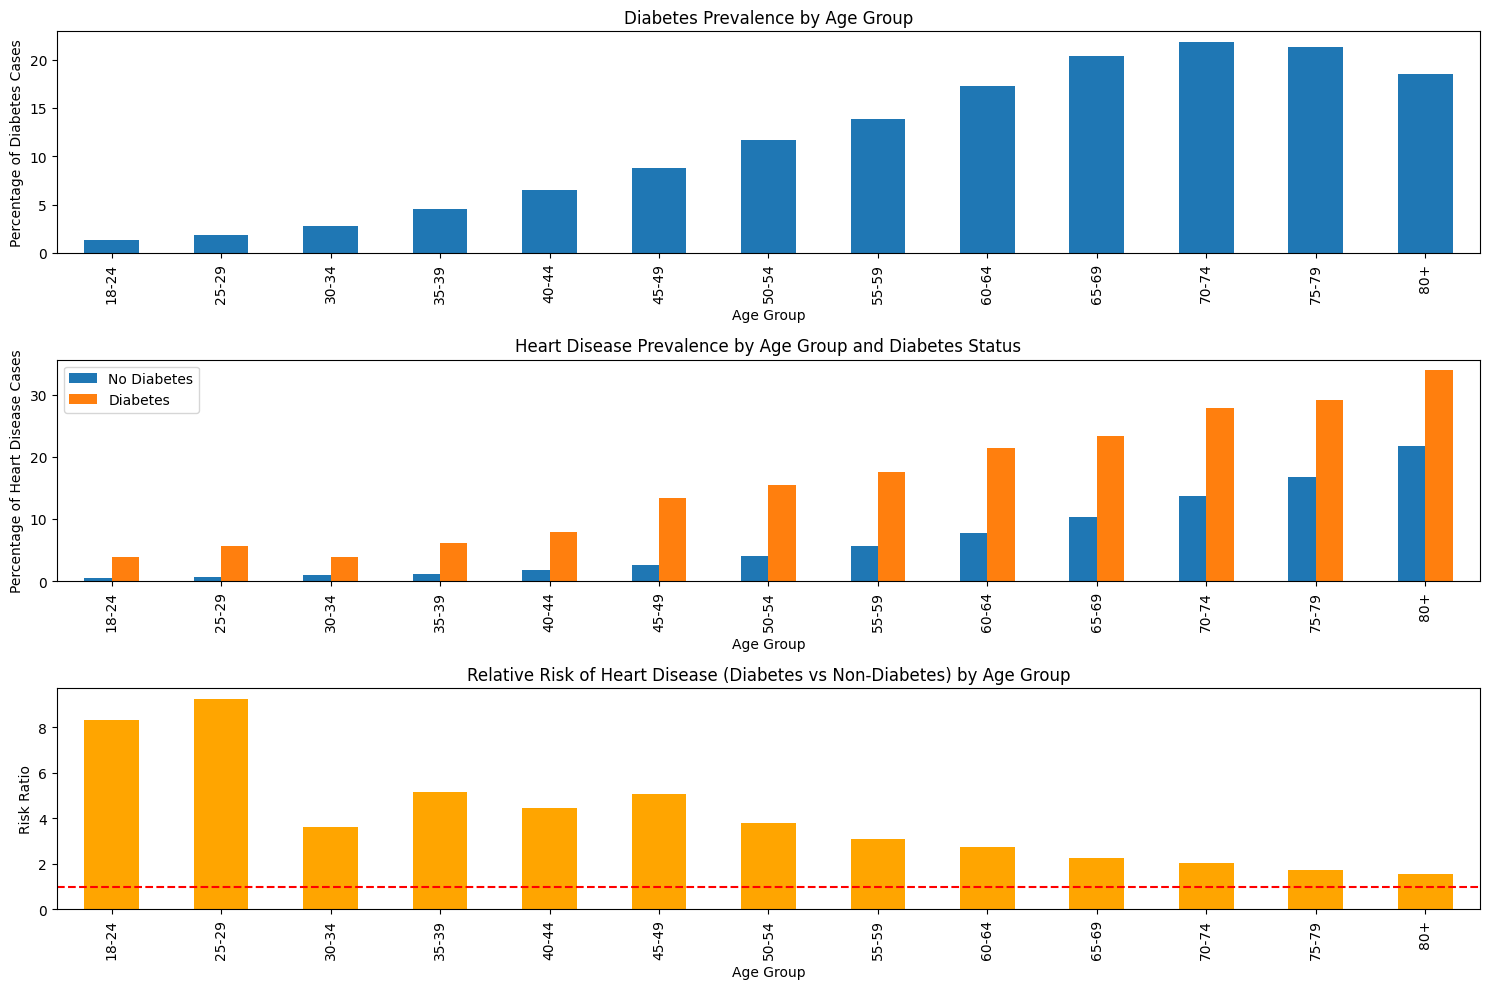


Risk Ratio of Heart Disease (Diabetics vs Non-Diabetics) by Age Group:
60-64: 2.75
50-54: 3.78
70-74: 2.05
65-69: 2.26
55-59: 3.11
80+: 1.56
35-39: 5.17
45-49: 5.08
25-29: 9.26
75-79: 1.74
40-44: 4.45
18-24: 8.32
30-34: 3.62


In [4]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create a copy of the data
X_copy = X.copy()
y_copy = y.copy()
df = pd.concat([X_copy, y_copy], axis=1)

# 1. Diabetes prevalence by age group
diabetes_by_age = df.groupby('AgeGroup', observed=True)['Diabetes_binary'].mean() * 100

# 2. Heart disease prevalence by age group and diabetes status
heart_disease_by_age_diabetes = df.groupby(['AgeGroup', 'Diabetes_binary'], observed=True)['HeartDiseaseorAttack'].mean() * 100

# Create visualizations
plt.figure(figsize=(15, 10))

# 1: Diabetes prevalence by age group
plt.subplot(3, 1, 1)
diabetes_by_age.plot(kind='bar')
plt.title('Diabetes Prevalence by Age Group')
plt.ylabel('Percentage of Diabetes Cases')
plt.xlabel('Age Group')

# 2: Heart disease prevalence by age group and diabetes status
plt.subplot(3, 1, 2)
ax2 = plt.gca()  # get current axis
heart_disease_by_age_diabetes.unstack().plot(kind='bar', ax=ax2)
plt.title('Heart Disease Prevalence by Age Group and Diabetes Status')
plt.ylabel('Percentage of Heart Disease Cases')
plt.xlabel('Age Group')
plt.legend(['No Diabetes', 'Diabetes'])

# Convert risk_ratios dict to Series for plotting

risk_ratios = {}
for age_group in df['AgeGroup'].unique():
    group_data = df[df['AgeGroup'] == age_group]
    heart_disease_diabetes = group_data[group_data['Diabetes_binary'] == 1]['HeartDiseaseorAttack'].mean()
    heart_disease_no_diabetes = group_data[group_data['Diabetes_binary'] == 0]['HeartDiseaseorAttack'].mean()
    risk_ratios[age_group] = heart_disease_diabetes / heart_disease_no_diabetes

risk_ratios_series = pd.Series(risk_ratios).sort_index()

# Risk Ratio
plt.subplot(3, 1, 3)
risk_ratios_series.plot(kind='bar', color='orange')
plt.title('Relative Risk of Heart Disease (Diabetes vs Non-Diabetes) by Age Group')
plt.ylabel('Risk Ratio')
plt.xlabel('Age Group')
plt.axhline(1, color='red', linestyle='--')  # Baseline: same risk

plt.tight_layout()
plt.show()


# Calculate risk ratio (relative risk) of heart disease for diabetics vs non-diabetics in each age group
risk_ratios = {}
for age_group in df['AgeGroup'].unique():
    group_data = df[df['AgeGroup'] == age_group]
    heart_disease_diabetes = group_data[group_data['Diabetes_binary'] == 1]['HeartDiseaseorAttack'].mean()
    heart_disease_no_diabetes = group_data[group_data['Diabetes_binary'] == 0]['HeartDiseaseorAttack'].mean()
    risk_ratios[age_group] = heart_disease_diabetes / heart_disease_no_diabetes

print("\nRisk Ratio of Heart Disease (Diabetics vs Non-Diabetics) by Age Group:")
for age_group, ratio in risk_ratios.items():
    print(f"{age_group}: {ratio:.2f}")

# Print the count of samples in each age group
# print("\nNumber of samples in each age group:")
# print(df['AgeGroup'].value_counts().sort_index())

## Corelation Exploration 
The highly related features to diabetes and whether they overlap with CVD's. 

In [5]:
candidate_vars = [
    'HeartDiseaseorAttack',
    'HighBP',              # High Blood Pressure
    'HighChol',            # High Cholesterol
    'CholCheck',           # Check Cholesterol
    'BMI',                 # Body Mass Index
    'Smoker',              # Smoker
    'PhysActivity',        # Physical Activity
    'Fruits', 'Veggies',   # Diet
    'HvyAlcoholConsump',   # Heavy Alcohol Consumption
    'HvyAlcoholConsump',   # Heavy Alcohol Consumption
    'AnyHealthcare',       # Any Healthcare
    'NoDocbcCost',         # No Doctor Cost
    'Education', 'Income'  # Education, Income
]

## Mediation Analysis
In this part, we're going to conduct a mediation analysis using logistic regression to quantify whether and how much the variable `Diabetes_binary` mediates the effect of `Age` on `HeartDiseaseorAttack`.
We are trying to answer "Does diabetes mediate (partially explain) the effect of age on heart disease?" , so we split the total effect into:

Direct effect: Age → Heart disease (not via diabetes)

Indirect effect: Age → Diabetes → Heart disease

Median effect / overall effect= mediation ratio

Here, logistic regression is used instead of linear regression because both outcomes (Diabetes_binary, HeartDiseaseorAttack) are binary. The coefficients from logistic regression are log odds, so while multiplication (for indirect effect) is common in linear mediation, here it's a rough approximation.

In [7]:
from statsmodels.formula.api import logit
import statsmodels.api as sm

med_df = df[['Age', 'Diabetes_binary', 'HeartDiseaseorAttack']].copy()
# Model a: Age → Diabetes_binary(mediator)
model_a = logit('Diabetes_binary ~ Age', data=med_df).fit()

# Model b+c: Age + Diabetes_binary → HeartDiseaseorAttack(direct and mediator path)
model_bc = logit('HeartDiseaseorAttack ~ Age + Diabetes_binary', data=med_df).fit()

# Model total effect: Age → HeartDiseaseorAttack(total path)
model_total = logit('HeartDiseaseorAttack ~ Age', data=med_df).fit()

a_coef = model_a.params['Age']
b_coef = model_bc.params['Diabetes_binary']
c_total = model_total.params['Age']
c_direct = model_bc.params['Age']

indirect_effect = a_coef * b_coef # simulates the chain rule of influence,
direct_effect = c_direct
total_effect = c_total

mediation_ratio = indirect_effect / total_effect

print(f"Path a (Age → Diabetes): {a_coef:.4f}")
print(f"Path b (Diabetes → Heart Disease): {b_coef:.4f}")
print(f"Total effect (Age → Heart Disease): {total_effect:.4f}")
print(f"Direct effect (Control Diabetes Age → Heart Disease): {direct_effect:.4f}")
print(f"Indirect effect (Age → Diabetes → Heart Disease): {indirect_effect:.4f}")
print(f"Mediation ratio, means the % of Age's effect on Heart Disease explained by Diabetes is {mediation_ratio:.2%}")

Optimization terminated successfully.
         Current function value: 0.386875
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.276453
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.284126
         Iterations 7
Path a (Age → Diabetes): 0.1887
Path b (Diabetes → Heart Disease): 1.0211
Total effect (Age → Heart Disease): 0.3118
Direct effect (Control Diabetes Age → Heart Disease): 0.2961
Indirect effect (Age → Diabetes → Heart Disease): 0.1926
Mediation ratio, means the % of Age's effect on Heart Disease explained by Diabetes is 61.78%


Diabetes is an important mediating variable in the relationship between “age → heart disease” , which explains 61.78% of the impact of age on heart disease .


If we can control diabetes in our age group, we may significantly delay or reduce the occurrence of heart disease!
Especially in the elderly, preventing diabetes is preventing heart disease.

### Stratified Analysis

Differences in the risk of heart disease caused by diabetes in young people. 

In [8]:
# 1: （BRFSS Age code ≤ 4 = age < 35）
young_df = df[df['Age'] <= 3]

# 2: split diabetic and non-diabetic
young_diabetic = young_df[young_df['Diabetes_binary'] == 1]
young_nondiabetic = young_df[young_df['Diabetes_binary'] == 0]

# 3: calculate heart disease rate
rate_diabetic = young_diabetic['HeartDiseaseorAttack'].mean()
rate_nondiabetic = young_nondiabetic['HeartDiseaseorAttack'].mean()

#4: calculate risk ratio
risk_ratio = rate_diabetic / rate_nondiabetic

print(f"Young people with diabetes(rate of heart disease in diabetic group): {rate_diabetic:.2%}")  
print(f"Young non-diabetes: rate of heart disease in non-diabetic group: {rate_nondiabetic:.2%}")
print(f"Hazared Ratio: risk ratio (diabetes vs non-diabetes): {risk_ratio:.2f} times")

Young people with diabetes(rate of heart disease in diabetic group): 4.32%
Young non-diabetes: rate of heart disease in non-diabetic group: 0.78%
Hazared Ratio: risk ratio (diabetes vs non-diabetes): 5.55 times


people under disease Among people under 35, those with diabetes have a 5.5 times higher risk of heart disease than those without diabetesit. It shows even in traditionally “healthy” young people, diabetes significantly increases cardiovascular risk.

"Diabetes prevention and control" for young people is not only a matter of controlling sugar, but also the first line of defense against heart disease

## **Counterfactual simulation**

If diabetes rates among young people fall by a certain percentage point, how much will heart disease rates fall? 

(“reducing the young diabetes rate from 5.4% to 4.4%” and then predict how many percentage points the overall heart disease rate can be reduced)

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Get young people data
young_df = df[df['Age'] <= 3].copy()
X = young_df[['Diabetes_binary', 'Age']]
y = young_df['HeartDiseaseorAttack']

# Model
clf = LogisticRegression().fit(X, y)

# Baseline prediction
baseline_preds = clf.predict_proba(X)[:, 1]
baseline_heart_rate = baseline_preds.mean()

# Simulate "diabetes rate decrease 1 pt"
# Find 1% of people with diabetes=1 and set them to 0
diabetics_idx = young_df[young_df['Diabetes_binary'] == 1].sample(frac=0.01, random_state=42).index
X_simulated = X.copy()
X_simulated.loc[diabetics_idx, 'Diabetes_binary'] = 0  # Simulate they "no diabetes"

# After intervention prediction
simulated_preds = clf.predict_proba(X_simulated)[:, 1]
simulated_heart_rate = simulated_preds.mean()

# Difference
impact = baseline_heart_rate - simulated_heart_rate

print(f"Current heart disease prediction rate: {baseline_heart_rate:.4%}")
print(f"After controlling diabetes: {simulated_heart_rate:.4%}")
print(f"Heart disease rate decrease: {impact:.4%} (due to diabetes rate decrease 1 pt)")


Current heart disease prediction rate: 0.8530%
After controlling diabetes: 0.8523%
Heart disease rate decrease: 0.0006% (due to diabetes rate decrease 1 pt)


100%|██████████| 1000/1000 [00:09<00:00, 102.08it/s]


Average heart disease rate decrease: 0.001358%
95% confidence interval: (0.000782%, 0.002119%)


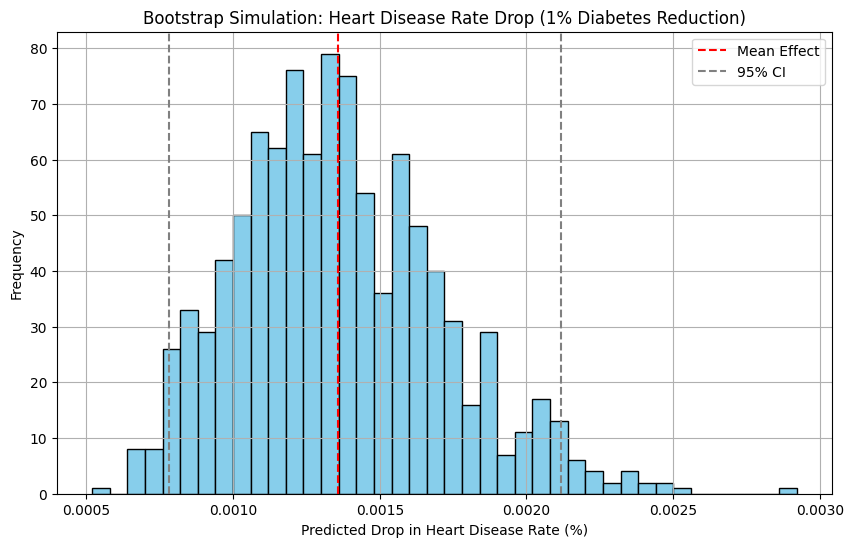

In [11]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm
import matplotlib.pyplot as plt

# Prepare data
young_df = df[df['Age'] <= 3].copy()
X_full = young_df[['Diabetes_binary', 'Age']]
y = young_df['HeartDiseaseorAttack'].values

# Model
clf = LogisticRegression().fit(X_full, y)

# Bootstrap simulation
n_iterations = 1000
differences = []

for _ in tqdm(range(n_iterations)):
    # Bootstrap sample
    sample = young_df.sample(frac=1, replace=True, random_state=None)
    X_sample = sample[['Diabetes_binary', 'Age']].copy()
    
    # Baseline prediction
    pred_base = clf.predict_proba(X_sample)[:, 1].mean()

    # Simulate intervention: randomly set 1% of diabetics to non-diabetes
    diabetic_idx = sample[sample['Diabetes_binary'] == 1].sample(frac=0.01, random_state=None).index
    X_sim = X_sample.copy()
    X_sim.loc[diabetic_idx, 'Diabetes_binary'] = 0

    # After simulation prediction
    pred_sim = clf.predict_proba(X_sim)[:, 1].mean()

    # Record difference
    differences.append(pred_base - pred_sim)

# Analyze results
diff_array = np.array(differences)
ci_lower, ci_upper = np.percentile(diff_array, [2.5, 97.5])
mean_diff = diff_array.mean()

print(f"Average heart disease rate decrease: {mean_diff:.6%}")
print(f"95% confidence interval: ({ci_lower:.6%}, {ci_upper:.6%})")

plt.figure(figsize=(10, 6))
plt.hist(diff_array * 100, bins=40, color='skyblue', edgecolor='k')
plt.axvline(mean_diff * 100, color='red', linestyle='--', label='Mean Effect')
plt.axvline(ci_lower * 100, color='gray', linestyle='--', label='95% CI')
plt.axvline(ci_upper * 100, color='gray', linestyle='--')
plt.title('Bootstrap Simulation: Heart Disease Rate Drop (1% Diabetes Reduction)')
plt.xlabel('Predicted Drop in Heart Disease Rate (%)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()


The confidence interval is completely above 0 , indicating that this is not a random error. Even a small intervention (1%) resulted in a steady decline in heart disease rates. This means: The intervention was statistically significant

### **Multi-level intervention simulation experiment**

In theory, the more deduction of diabetes prevalence, the more decrease in CVD could be expected, but there's no way that we can deduct the number infinitely. 

100%|██████████| 10/10 [00:00<00:00, 319.29it/s]


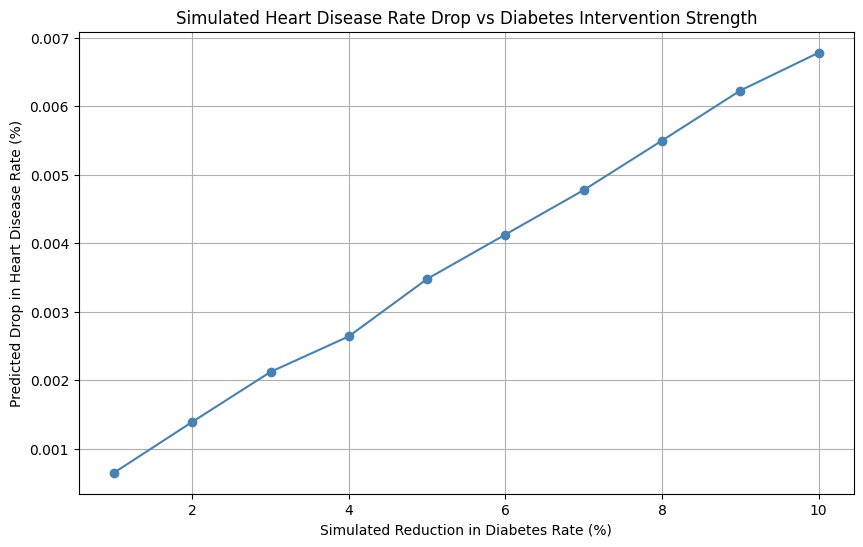

1% intervention → ↓ 0.0006% heart disease rate
2% intervention → ↓ 0.0014% heart disease rate
3% intervention → ↓ 0.0021% heart disease rate
4% intervention → ↓ 0.0026% heart disease rate
5% intervention → ↓ 0.0035% heart disease rate
6% intervention → ↓ 0.0041% heart disease rate
7% intervention → ↓ 0.0048% heart disease rate
8% intervention → ↓ 0.0055% heart disease rate
9% intervention → ↓ 0.0062% heart disease rate
10% intervention → ↓ 0.0068% heart disease rate


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm

# Data preparation
young_df = df[df['Age'] <= 3].copy()
X_full = young_df[['Diabetes_binary', 'Age']]
y = young_df['HeartDiseaseorAttack'].values

# Model fitting
clf = LogisticRegression().fit(X_full, y)

# Baseline prediction rate
baseline_rate = clf.predict_proba(X_full)[:, 1].mean()

# Intervention rate list (1% to 10%)
intervention_rates = list(range(1, 11))
drops = []

# Multi-level simulation
for rate in tqdm(intervention_rates):
    X_sim = X_full.copy()
    # Find p% of diabetics and set them to non-diabetes
    diabetic_idx = young_df[young_df['Diabetes_binary'] == 1].sample(frac=rate/100, random_state=42).index
    X_sim.loc[diabetic_idx, 'Diabetes_binary'] = 0
    pred_sim = clf.predict_proba(X_sim)[:, 1].mean()
    drop = baseline_rate - pred_sim
    drops.append(drop)

# Visualization
plt.figure(figsize=(10, 6))
plt.plot(intervention_rates, [d * 100 for d in drops], marker='o', color='steelblue')
plt.title('Simulated Heart Disease Rate Drop vs Diabetes Intervention Strength')
plt.xlabel('Simulated Reduction in Diabetes Rate (%)')
plt.ylabel('Predicted Drop in Heart Disease Rate (%)')
plt.grid(True)
plt.show()

# Output values
for p, d in zip(intervention_rates, drops):
    print(f"{p}% intervention → ↓ {d*100:.4f}% heart disease rate")


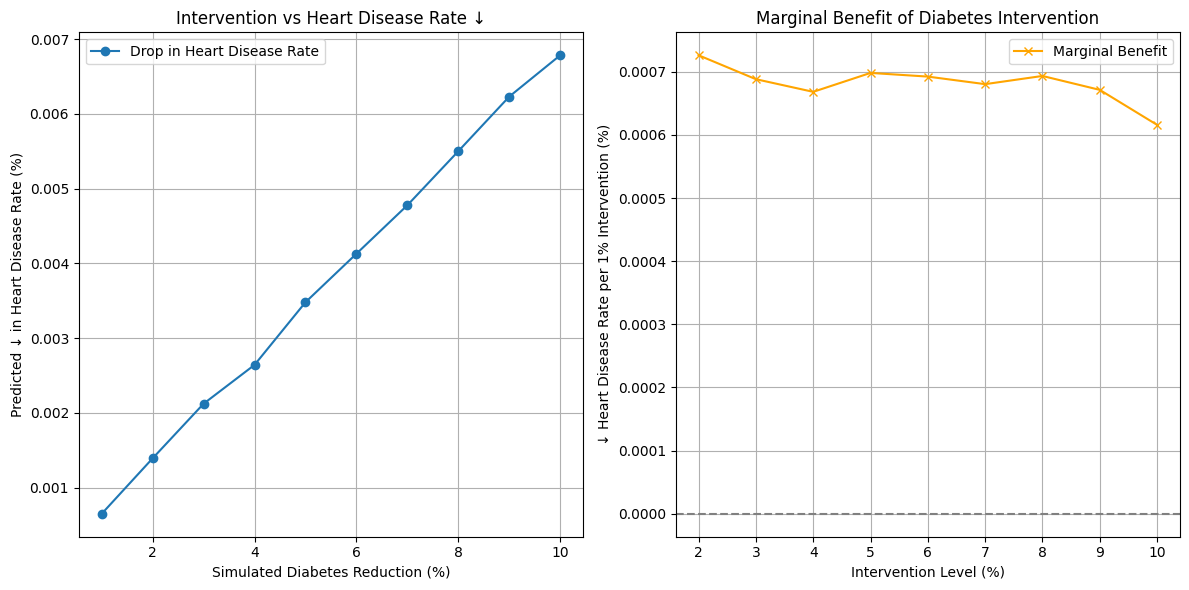

In [33]:
import numpy as np
from scipy.ndimage import gaussian_filter1d
from sklearn.linear_model import LinearRegression

# Calculate marginal benefit (difference)
marginal = np.diff(drops)
smoothed_marginal = gaussian_filter1d(marginal, sigma=1)

# Visualize trend and marginal changes
plt.figure(figsize=(12, 6))

# Main trend chart
plt.subplot(1, 2, 1)
plt.plot(intervention_rates, [d*100 for d in drops], marker='o', label='Drop in Heart Disease Rate')
plt.title('Intervention vs Heart Disease Rate ↓')
plt.xlabel('Simulated Diabetes Reduction (%)')
plt.ylabel('Predicted ↓ in Heart Disease Rate (%)')
plt.grid(True)
plt.legend()

# Marginal change chart
plt.subplot(1, 2, 2)
plt.plot(intervention_rates[1:], [m*100 for m in smoothed_marginal], marker='x', color='orange', label='Marginal Benefit')
plt.axhline(0, linestyle='--', color='gray')
plt.title('Marginal Benefit of Diabetes Intervention')
plt.xlabel('Intervention Level (%)')
plt.ylabel('↓ Heart Disease Rate per 1% Intervention (%)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


## **Conclusion**

- Diabetes is strongly and significantly associated with higher risk of cardiovascular disease. 

- On average, having diabetes increases the probability of having CVD by about 9.8 percentage points. 

- This suggests that diabetes is an important risk factor for cardiovascular disease in this population.
